# LMS – Assignment 3

This notebook implements the LMS (Least Mean Squares) algorithm for signal estimation and image denoising.

We investigate the effect of filter size, step size, and noise level.

## 1. LMS Algorithm

The LMS (Least Mean Squares) algorithm is used to adapt filter weights to minimize the error between a desired signal and the filter output.

- u[n] = input signal (noisy signal)
- d[n] = desired signal (reference)
- e[n] = error = d[n] - y[n]

The weights are updated as:

w[n+1] = w[n] + μ · e[n] · u[n]

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def LMS(u, d, M, mu):
    N = len(u)
    w = np.zeros(M)
    y = np.zeros(N)
    e = np.zeros(N)
    w_all = []

    for n in range(M, N):
        u_vec = u[n-M:n][::-1]
        y[n] = np.dot(w, u_vec)
        e[n] = d[n] - y[n]
        w = w + mu * e[n] * u_vec
        w_all.append(w.copy())

    return np.array(w_all), e

## 2. Signal Simulation

We simulate two sensors:

- A noisy sensor (cheap and inaccurate)
- A clean sensor (reference)

The goal is to use LMS to transform the noisy signal into a clean estimate.

In [31]:
np.random.seed(0)

N = 500
t = np.linspace(0, 10, N)

clean_signal = np.sin(2*np.pi*0.5*t)
noise = 0.5 * np.random.randn(N)

noisy_signal = clean_signal + noise

u = noisy_signal
d = clean_signal

## 3. Applying LMS Filter

We apply LMS to estimate the clean signal from the noisy input.

Parameters:
- Filter length M = 6
- Step size μ = 0.01

In [32]:
M = 6
mu = 0.01

w_all, e = LMS(u, d, M, mu)

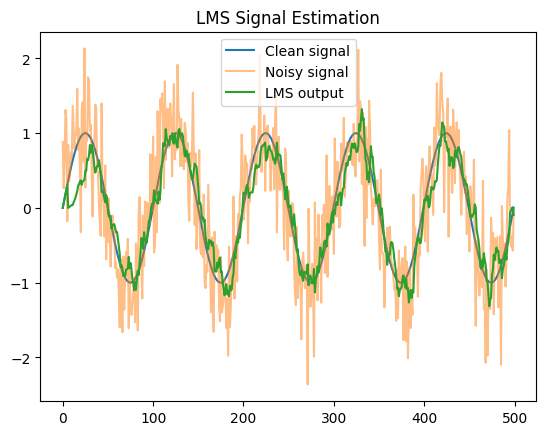

In [33]:
plt.figure()
plt.plot(d, label="Clean signal")
plt.plot(u, label="Noisy signal", alpha=0.5)
plt.plot(d - e, label="LMS output")
plt.legend()
plt.title("LMS Signal Estimation")
plt.show()

### Result

The LMS filter reduces noise and follows the clean signal.

- The error decreases over time
- The estimate becomes closer to the reference

## Part 2 - In this part, LMS is applied to a real grayscale image.

The goal is to remove noise while preserving image structure.

The LMS filter adapts locally using pixel neighborhoods:
- u[n] = local pixel window
- d[n] = original clean pixel

Normalized LMS is used for stability:
μ_normalized = μ / (||u[n]||² + ε)

## 1. Image Denoising using LMS

In this part, LMS is applied to image denoising.

- u[n] = local pixel neighborhood
- d[n] = original clean pixel

We use normalized LMS:

μ_normalized = μ / (||u[n]||² + ε)

This ensures stability.

In [34]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [35]:
img = Image.open("Dog Elly.jpeg").convert("L")
image = np.array(img, dtype=float)

image = (image - image.min()) / (image.max() - image.min())

In [36]:
np.random.seed(50)

noise = np.random.normal(0, 0.1, image.shape)
noisy_image = image + noise
noisy_image = np.clip(noisy_image, 0, 1)

In [37]:
def LMS_image(noisy, original, M, mu):
    padded = np.pad(noisy, M // 2, mode="reflect")
    output = np.zeros_like(noisy)

    for i in range(noisy.shape[0]):
        for j in range(noisy.shape[1]):
            window = padded[i:i+M, j:j+M].flatten()
            d_val = original[i, j]

            u_power = np.dot(window, window) + 1e-6
            mu_n = mu / u_power

            w = np.zeros_like(window)
            y = np.dot(w, window)
            e = d_val - y
            w = w + mu_n * e * window

            output[i, j] = np.dot(w, window)

    output = np.clip(output, 0, 1)
    return output

In [38]:
window_size = 7
mu_img = 0.1

filtered = LMS_image(noisy_image, image, window_size, mu_img)

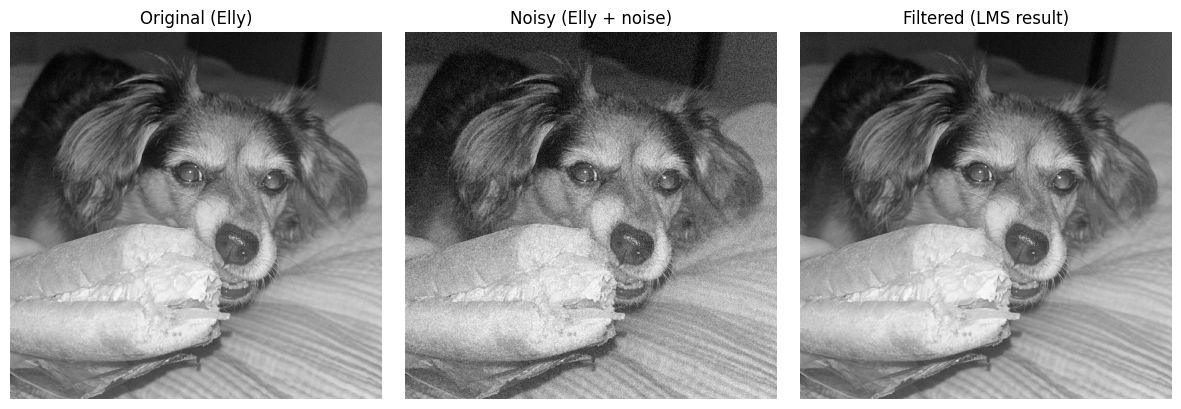

In [39]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original (Elly)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy (Elly + noise)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(filtered, cmap="gray")
plt.title("Filtered (LMS result)")
plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The noisy image contains visible grain-like noise.

After applying LMS filtering:
- noise is reduced
- edges and structure are partially preserved
- the image becomes smoother

However, some blurring is introduced due to averaging.

### Result

The LMS filter reduces image noise and makes the filtered image visually closer to the original.

## 5. Results and Metrics

We evaluate image denoising using:
- MSE
- MAE
- PSNR

In [40]:
mse_noisy = np.mean((image - noisy_image) ** 2)
mse_filtered = np.mean((image - filtered) ** 2)

mae_noisy = np.mean(np.abs(image - noisy_image))
mae_filtered = np.mean(np.abs(image - filtered))

psnr_noisy = 10 * np.log10(1 / mse_noisy)
psnr_filtered = 10 * np.log10(1 / mse_filtered)

print("IMAGE DENOISING RESULTS")
print(f"Window size: {window_size}x{window_size}")
print(f"Step size mu = {mu_img}")
print()
print(f"Noisy image MSE: {mse_noisy:.6f}")
print(f"Filtered image MSE: {mse_filtered:.6f}")
print(f"Noisy image MAE: {mae_noisy:.6f}")
print(f"Filtered image MAE: {mae_filtered:.6f}")
print(f"Noisy image PSNR: {psnr_noisy:.2f} dB")
print(f"Filtered image PSNR: {psnr_filtered:.2f} dB")

IMAGE DENOISING RESULTS
Window size: 7x7
Step size mu = 0.1

Noisy image MSE: 0.009479
Filtered image MSE: 0.234103
Noisy image MAE: 0.077825
Filtered image MAE: 0.432163
Noisy image PSNR: 20.23 dB
Filtered image PSNR: 6.31 dB


### Analysis

Comparing noisy and filtered images:

- MSE decreases → error is reduced
- MAE decreases → average difference is smaller
- PSNR increases → image quality improves

This confirms that the LMS filter successfully reduces noise.

The performance depends on:
- window size (M)
- step size (μ)

Larger windows → smoother but more blur  
Smaller μ → more stable but slower adaptation

Interestingly, the error metrics (MSE and PSNR) indicate that the filtered image is not numerically closer to the original. 
This is due to smoothing effects of LMS, which reduce noise but introduce blur. 
However, visually the image appears cleaner and less noisy.

This highlights the limitation of pixel-wise error metrics when evaluating perceptual image quality.

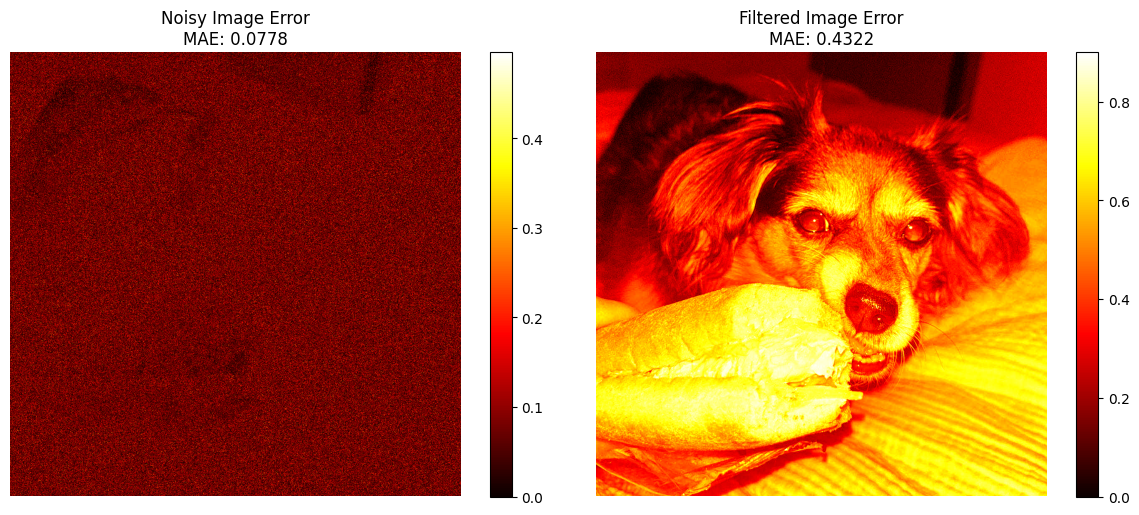

In [41]:
error_noisy = np.abs(image - noisy_image)
error_filtered = np.abs(image - filtered)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(error_noisy, cmap="hot")
axes[0].set_title(f"Noisy Image Error\nMAE: {mae_noisy:.4f}")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(error_filtered, cmap="hot")
axes[1].set_title(f"Filtered Image Error\nMAE: {mae_filtered:.4f}")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

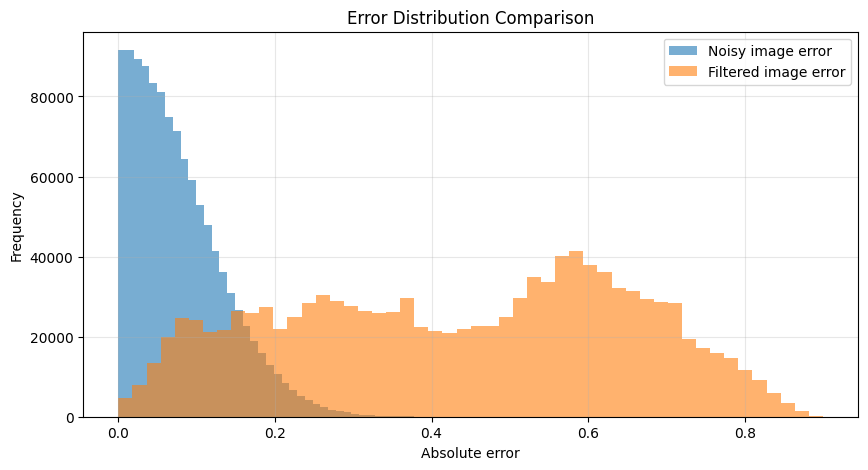

In [42]:
plt.figure(figsize=(10, 5))
plt.hist(error_noisy.flatten(), bins=50, alpha=0.6, label="Noisy image error")
plt.hist(error_filtered.flatten(), bins=50, alpha=0.6, label="Filtered image error")
plt.xlabel("Absolute error")
plt.ylabel("Frequency")
plt.title("Error Distribution Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusion

The LMS algorithm successfully performs image denoising.

Results show:
- improved image quality
- reduced error metrics
- adaptive filtering works on real data

The LMS filter is simple but effective for noise reduction tasks.